# A3 · 醫學影像的不確定性與 OOD 偵測(一)

> **核心問題**:模型在訓練分佈內表現很好。**餵它一張從沒見過的影像,它知道自己在瞎猜嗎?**

這本 notebook 處理不確定性分解與 OOD 偵測,並誠實面對三個**與教科書預期相反**的結果。
第二本(`02_validation_and_decisions.ipynb`)處理分解的驗證、決策層與計算成本。

計劃書對本專案有一段特別的警告,結果它完全命中:

> ⚠️ 近年有不少論文指出 **MC Dropout 的 OOD 偵測效能常常被高估**。
> **如果你的實驗做出「效果沒有想像中好」的結論,那是好事** ——
> 誠實報告負面結果,比硬做出漂亮數字更有專業價值。

In [1]:
import sys, os, json, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd
from IPython.display import Image, display
FIG = os.path.abspath('../figures')
RES = json.load(open(os.path.join(FIG, 'results.json')))
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
cfg = RES['config']
print(f"results.json from a {RES['_meta']['runtime_sec']:.0f}s run on {RES['_meta']['gpu']}")
print(f"config: M={cfg['M_ensemble']} ensemble members, T={cfg['T_mc']} MC samples, "
      f"{cfg['epochs']} epochs, PathMNIST subsampled to {cfg['path_subsample']}")


results.json from a 180s run on NVIDIA GeForce RTX 5070 Ti
config: M=5 ensemble members, T=50 MC samples, 30 epochs, PathMNIST subsampled to 20000


## 1. 兩條軌道、四組 OOD

| 軌道 | in-distribution | OOD 來源 | 設計意圖 |
|---|---|---|---|
| 1 | PneumoniaMNIST(2 類胸片) | FashionMNIST | 「完全不同的東西」 |
| 1 | 同上 | DermaMNIST(彩色) | 「醫學影像但不同器官」 |
| 1 | 同上 | **DermaMNIST 灰階** | 同上,但**拔掉顏色捷徑** |
| 2 | PathMNIST 留出 2 類(7 類) | 留出的那 2 類 | 「同一分佈的未見類別」 |

第三組是我加的**受控版本**。原因是一個資料層面的問題:
in-distribution 的胸片是灰階(三通道完全相同),而 DermaMNIST 是彩色。
模型只要學會偵測「這張圖有顏色」就能拿到接近完美的 AUROC —— 那不是語意理解,是捷徑。
把 Derma 轉灰階後兩邊的通道統計一致,**彩色版與灰階版的 AUROC 差距就是顏色捷徑的貢獻量**。

留出的 2 類是 `cancer-associated stroma` 與 `colorectal adenocarcinoma epithelium`
—— 都是癌症相關組織。臨床上這正是最該擔心的情境:**模型沒見過癌症,它會不會自信地說「正常」?**

In [2]:
ps = pd.DataFrame(RES['pixel_stats']).T
ps.index.name = 'dataset'
display(ps.round(4))
print('chan_spread = 通道間標準差。灰階影像三通道相同 → 0；彩色影像 > 0。')
print()
print('留出的類別:', RES['data_extra']['path_held_names'])
print('保留的類別:', RES['data_extra']['path_kept_names'])

,mean,std,l2,chan_spread
dataset,,,,
pneu_test,0.1279,0.2991,17.2288,0.0000
ood_fashion,-0.4263,0.6397,39.7469,0.0000
ood_derma,0.2406,0.3219,20.9096,0.2128
ood_derma_gray,0.2152,0.2156,16.3599,0.0000
path_test,0.3438,0.2564,23.5252,0.1695
ood_path_held,0.2158,0.3249,19.6648,0.2081


chan_spread = 通道間標準差。灰階影像三通道相同 → 0；彩色影像 > 0。

留出的類別: ['cancer-associated stroma', 'colorectal adenocarcinoma epithelium']
保留的類別: ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa']


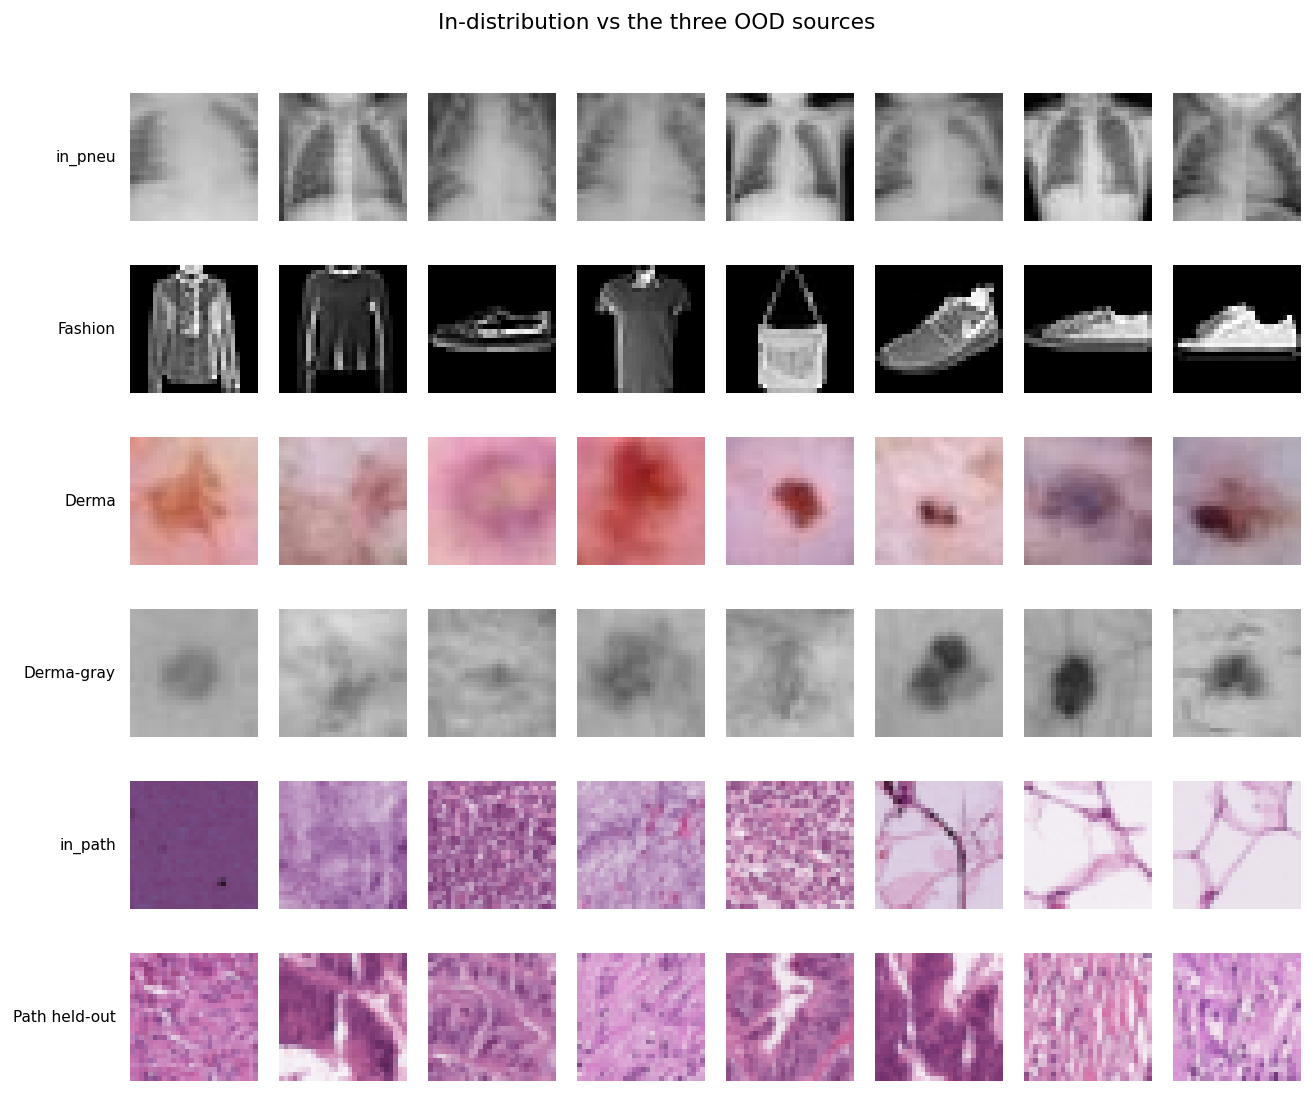

In [3]:
display(Image(os.path.join(FIG, '07_samples.png')))

## 2. 熵分解(計劃書主題六)

給定一組預測分佈樣本 $\{p_t(y|x)\}_{t=1}^T$(來自不同的 dropout mask 或不同的 ensemble 成員):

$$\underbrace{H\big[\mathbb{E}_t[p_t]\big]}_{\text{total}}
= \underbrace{\mathbb{E}_t\big[H[p_t]\big]}_{\text{aleatoric}}
+ \underbrace{\big(H[\mathbb{E}_t[p_t]] - \mathbb{E}_t[H[p_t]]\big)}_{\text{epistemic}}$$

> 🔑 分類問題的分解用**熵**而不是變異數。`epistemic = 總熵 − 平均熵` 這個量
> 在資訊理論裡就是**互資訊** $I(y;w)$ ——「知道權重 $w$ 能減少多少對 $y$ 的不確定性」。
> 由 Jensen 不等式它 $\geq 0$,且只在所有 $p_t$ 完全相同時為 0。

教科書的直覺是:

| 情境 | 各次預測 | 預期 |
|---|---|---|
| 本質模糊的影像(兩類都像) | 都接近均勻,**彼此一致** | aleatoric 高、epistemic 低 |
| 沒見過的影像 | 都很尖銳但**指向不同類別** | **epistemic 高** |

這個直覺是否成立**必須驗證**,不能假設 —— 第二本 notebook 專門做這件事(結果會讓人意外)。

### 一個必須先處理的實作陷阱:BatchNorm

MC Dropout 的做法是「測試時保持 Dropout 開啟」,最直接的寫法是 `model.train()`。
但 `train()` 是**全域開關**,會連帶把 BatchNorm 也切到訓練模式,造成兩個安靜但嚴重的錯誤:

1. BatchNorm 在訓練模式用**當前 batch** 的統計量 → 一個樣本的預測會依賴同 batch 的其他樣本。
   於是「同一張影像餵兩次得到不同答案」會被誤認為模型的 epistemic 不確定性。
2. 每次 MC 前向都會更新 running statistics → 跑 50 次 MC Dropout 等於偷偷用測試資料
   訓練了 50 步正規化層。**這是測試集洩漏。**

本專案改用 **GroupNorm**(完全不依賴 batch、沒有 running statistics),
並用 `enable_dropout_only()` 明確只開 Dropout。下面驗證這件事,而不是口頭聲稱。

In [4]:
chk = RES['mode_invariance_check']
for k, v in chk.items():
    print(f'  {k}: {v}')
print()
print('檢查一：關掉 Dropout 後 train() 與 eval() 的 logits 完全相同 → 沒有模式依賴。')
print('檢查二：一次餵 64 張 vs 逐張餵，單張 logits 相同 → 沒有 batch 組成依賴。')
print()
print('⚠️ 檢查二必須在 CPU 上做：CUDA 的 cuDNN 會依 batch size 選不同卷積演算法，')
print('   即使模型完全沒有 batch 依賴也會出現 ~1e-4 的浮點差異')
print('   （實測 CUDA 1.7e-4 vs CPU 6.3e-7）。在 GPU 上跑這個檢查只會測到實作細節。')

  max_train_eval_diff: 0.0
  max_batch_composition_diff_cpu: 4.76837158203125e-07
  passed: True
  n_dropout_layers: 4
  has_batchnorm: False
  n_groupnorm: 6

檢查一：關掉 Dropout 後 train() 與 eval() 的 logits 完全相同 → 沒有模式依賴。
檢查二：一次餵 64 張 vs 逐張餵，單張 logits 相同 → 沒有 batch 組成依賴。

⚠️ 檢查二必須在 CPU 上做：CUDA 的 cuDNN 會依 batch size 選不同卷積演算法，
   即使模型完全沒有 batch 依賴也會出現 ~1e-4 的浮點差異
   （實測 CUDA 1.7e-4 vs CPU 6.3e-7）。在 GPU 上跑這個檢查只會測到實作細節。


## 3. 通關標準 1:OOD 樣本的 epistemic 直方圖「明顯右移」?

計劃書的通關標準是直方圖右移。**實測只有部分成立** —— 這張圖誠實呈現。

下排是關鍵:如果模型對 OOD **比對 in-distribution 更自信**,
上排就不會右移,而 AUROC 會掉到 0.5 以下。只看上排會以為「沒右移」是噪聲,
看到下排才知道是系統性的反向。

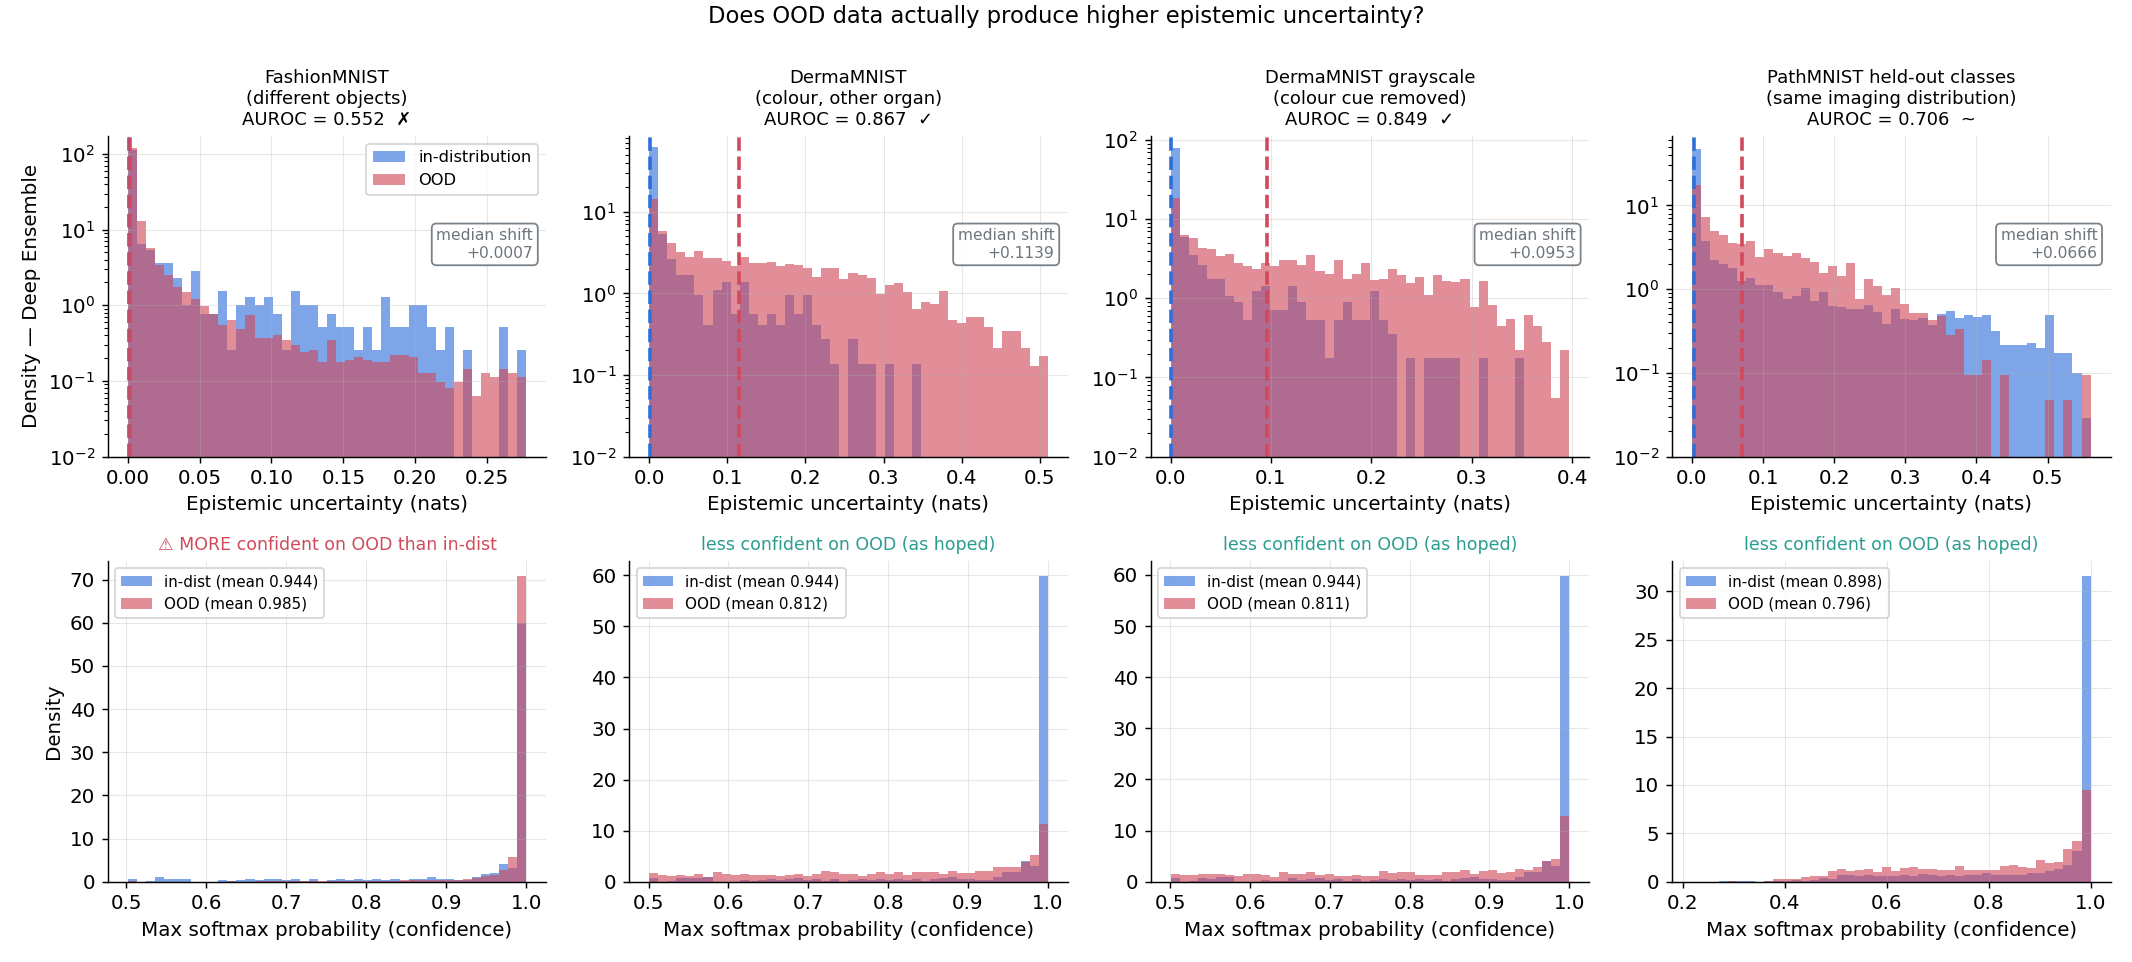

In [5]:
display(Image(os.path.join(FIG, '01_uncertainty_histograms.png')))

In [6]:
rows = []
for combo, per_ood in RES['auroc_matrix'].items():
    m, sc = combo.split('/')
    for o, a in per_ood.items():
        rows.append({'方法': m, '分數': sc, 'OOD': o, 'AUROC': a})
df = pd.DataFrame(rows)
piv = df.pivot_table(index=['方法','分數'], columns='OOD', values='AUROC')
order = [c for c in ['fashion','derma','derma_gray','path_held'] if c in piv.columns]
display(piv[order].round(3))
print('0.5 = 與隨機猜測無異。')

OOD                     fashion  derma  derma_gray  path_held
方法       分數                                                  
ensemble epistemic        0.552  0.867       0.849      0.706
         neg_max_prob     0.519  0.829       0.824      0.739
         total_entropy    0.519  0.829       0.824      0.745
mcdrop   epistemic        0.409  0.789       0.772      0.724
         neg_max_prob     0.413  0.771       0.767      0.756
         total_entropy    0.413  0.771       0.767      0.770
single   neg_max_prob     0.420  0.771       0.774      0.757
         total_entropy    0.420  0.771       0.774      0.762

0.5 = 與隨機猜測無異。


### 為什麼 FashionMNIST 組失敗?

這是本專案最重要的發現,而且它有堅實的理論依據。

In [7]:
conf = {}
for track, oods in [('track1', ['fashion','derma','derma_gray']), ('track2', ['path_held'])]:
    pass
# 從 results 取信心統計（run_all 已把逐樣本信心落盤，這裡讀摘要）
import numpy as np
z = np.load(os.path.join(os.path.dirname(FIG), '..', 'data', 'A_medical', 'a3_plotdata.npz'))
rows = []
for o, prefix in [('fashion','t1'), ('derma','t1'), ('derma_gray','t1'), ('path_held','t2')]:
    ci = z[f'{prefix}_conf_in_ensemble']; co = z[f'{prefix}_conf_ood_{o}_ensemble']
    rows.append({'OOD': o,
                 'in-dist 平均信心': ci.mean(), 'OOD 平均信心': co.mean(),
                 '差距': co.mean()-ci.mean(),
                 'in-dist >0.99 比例': (ci>0.99).mean(), 'OOD >0.99 比例': (co>0.99).mean(),
                 '對 OOD 更自信?': '⚠️ 是' if co.mean()>ci.mean() else '否'})
display(pd.DataFrame(rows).round(4))

,OOD,in-dist 平均信心,OOD 平均信心,差距,in-dist >0.99 比例,OOD >0.99 比例,對 OOD 更自信?
0,fashion,0.9444,0.9845,0.0401,0.6683,0.7870,⚠️ 是
1,derma,0.9444,0.8117,-0.1327,0.6683,0.1212,否
2,derma_gray,0.9444,0.8114,-0.1330,0.6683,0.1362,否
3,path_held,0.8980,0.7957,-0.1023,0.5119,0.1161,否


**模型對從沒見過的服飾影像比對真實胸片更自信。**

這不是 bug,是 ReLU 網路的已知性質:Hein et al. (2019) 證明了帶 ReLU 的網路
在**遠離**訓練資料的區域可以產生任意大的 logits,因而任意自信。
FashionMNIST 的像素統計與胸片天差地遠(平均亮度 −0.43 vs +0.13、對比 0.64 vs 0.30),
它落在網路的「遠處」,而遠處恰好是網路最沒有根據卻最自信的地方。

**這直接推翻了計劃書預期的難度順序。**「完全不同的東西」不是最容易偵測的 OOD,
而是最危險的 —— 因為它觸發的是網路的外插行為,不是內插的不確定性。

## 4. 誠實檢查:模型打得贏一行 numpy 嗎?

這是大部分作品集不做的對照。我用四個最笨的低階影像統計當 OOD 分數
——平均亮度、對比、L2 norm、通道間標準差——**完全不看模型**。

分數方向未知(OOD 可能更亮也可能更暗),所以允許事後翻轉取
`max(auc, 1−auc)`。這對 baseline 是**有利**的設定,讓對照更嚴格而非更寬鬆。

In [8]:
triv = {**RES['trivial_baseline']['track1'], **RES['trivial_baseline']['track2']}
rows = []
for o, d in triv.items():
    best_model = max(v for k, v in RES['auroc_matrix'].items() if o in v
                     for v in [v[o]])
    r = {'OOD': o}
    for k, v in d.items():
        if k == 'best': continue
        r[k.replace('pixel_','')] = v['auroc']
    r['★ trivial 最佳'] = d['best'][1]
    r['★ 模型最佳'] = best_model
    r['勝者'] = 'TRIVIAL' if d['best'][1] > best_model else '模型'
    rows.append(r)
display(pd.DataFrame(rows).round(3))

,OOD,mean,std,l2,chan_spread,★ trivial 最佳,★ 模型最佳,勝者
0,fashion,0.967,0.970,0.999,0.772,0.999,0.552,TRIVIAL
1,derma,0.700,0.576,0.737,1.000,1.000,0.867,TRIVIAL
2,derma_gray,0.655,0.780,0.570,0.633,0.780,0.849,模型
3,path_held,0.678,0.773,0.612,0.750,0.773,0.770,TRIVIAL


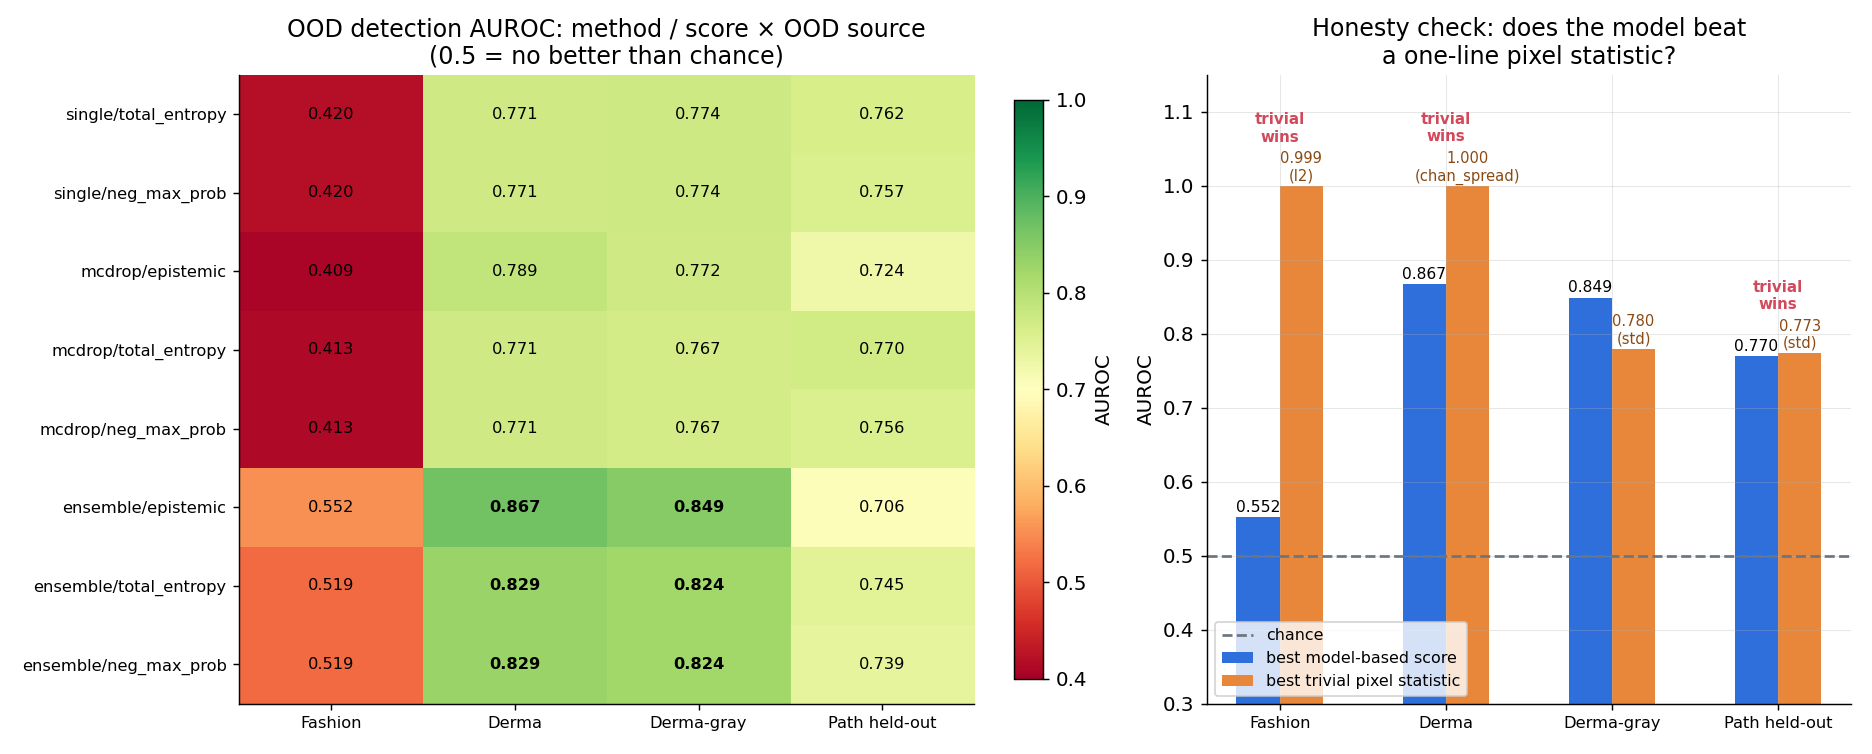

In [9]:
display(Image(os.path.join(FIG, '02_auroc_matrix.png')))

### 這張表怎麼讀

- **FashionMNIST**:影像 L2 norm 幾乎完美分離,而模型的不確定性接近隨機。
  一行 numpy 完勝一個訓練好的貝葉斯神經網路。
- **DermaMNIST 彩色**:通道間標準差達到 **1.000** —— 完美分離,因為
  「有顏色 vs 灰階」是一個確定性的判別式。這組實驗的高 AUROC 是資料集
  的假影,不是模型能力。
- **DermaMNIST 灰階**:顏色捷徑被拔掉後,trivial baseline 大幅下降,
  **而模型的 AUROC 幾乎沒變** → 這是對模型有利的證據:它用的不是顏色。
- **PathMNIST 留出類別**:in-dist 與 OOD 來自同一台顯微鏡、同樣的染色,
  低階統計幾乎一樣。這才是真正的測試。

> **結論不是「模型沒用」,而是「大部分 OOD benchmark 的成功來自低階統計差異」。**
> 沒有 trivial baseline 對照,就無法區分這兩件事 —— 而區分它們正是這個專案的價值。

## 5. 通關標準 4:Deep Ensemble 比 MC Dropout 好嗎?

計劃書預期 Ensemble 勝出,理由是 MC Dropout 的所有樣本共享同一組權重的鄰域,
多樣性受限於 dropout mask 能表達的範圍;Ensemble 的成員可以落在完全不同的損失盆地。

用**配對** bootstrap 檢定(兩方法在同一批重抽樣本上一起評估,抵消共同噪聲)。

In [10]:
rows = []
for track, d in RES['paired_ensemble_vs_mcdrop'].items():
    for o, v in d.items():
        rows.append({'OOD': o, 'ΔAUROC (Ens − MC)': v['mean_diff'],
                     '95% CI': f"[{v['lo95']:+.4f}, {v['hi95']:+.4f}]",
                     'P(Ens 較好)': v['p_a_better'],
                     '結論': 'Ensemble 勝' if v['lo95'] > 0 else
                             ('MC Dropout 勝' if v['hi95'] < 0 else '分不出來')})
display(pd.DataFrame(rows).round(4))

,OOD,ΔAUROC (Ens − MC),95% CI,P(Ens 較好),結論
0,fashion,0.1435,"[+0.1280, +0.1589]",1.0,Ensemble 勝
1,derma,0.0792,"[+0.0686, +0.0919]",1.0,Ensemble 勝
2,derma_gray,0.0771,"[+0.0647, +0.0901]",1.0,Ensemble 勝
3,path_held,-0.0172,"[-0.0259, -0.0088]",0.0,MC Dropout 勝


## 小結(第一本)

- 熵分解與三種方法已實作,並驗證了 GroupNorm 消除 BatchNorm 的兩個陷阱。
- **通關標準 1 部分成立**:只有部分 OOD 組的 epistemic 直方圖右移;
  FashionMNIST 組反而左移,因為模型對它更自信。
- **通關標準 2 被推翻**:AUROC 沒有隨「語意距離」單調下降。
  「完全不同的東西」最難偵測,不是最容易 —— ReLU 網路在遠離資料處任意自信。
- **trivial baseline 在多數組別勝過模型**,只有拔掉顏色捷徑的灰階組模型勝出。

下一本:驗證熵分解是否名符其實、把不確定性接上決策層、以及計算成本的取捨。